# LSTM Model
This markdown details the development and refinement ofthe LSTM model for the 24 hour time period. The MAE this model produced didn't come close to the benchmark set by the forecast data provided.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


## Import Data

In [28]:
demandNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/totaldemand_nsw.csv",
                 index_col=[0],
                 parse_dates=[0],
                 date_format = '%d/%m/%Y %H:%M')

print(demandNSW)

                     TOTALDEMAND REGIONID
DATETIME                                 
2010-01-01 00:00:00      8038.00     NSW1
2010-01-01 00:30:00      7809.31     NSW1
2010-01-01 01:00:00      7483.69     NSW1
2010-01-01 01:30:00      7117.23     NSW1
2010-01-01 02:00:00      6812.03     NSW1
...                          ...      ...
2021-03-17 22:00:00      7419.77     NSW1
2021-03-17 22:30:00      7417.91     NSW1
2021-03-17 23:00:00      7287.32     NSW1
2021-03-17 23:30:00      7172.39     NSW1
2021-03-18 00:00:00      7094.51     NSW1

[196513 rows x 2 columns]


In [29]:
tempNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/temperature_nsw.csv")
tempNSW['DATETIME'] = pd.to_datetime(tempNSW['DATETIME'], format='%d/%m/%Y %H:%M')
tempNSW.drop(['LOCATION'], axis=1, inplace=True)
print(tempNSW)

                  DATETIME  TEMPERATURE
0      2010-01-01 00:00:00         23.1
1      2010-01-01 00:01:00         23.1
2      2010-01-01 00:30:00         22.9
3      2010-01-01 00:50:00         22.7
4      2010-01-01 01:00:00         22.6
...                    ...          ...
220321 2021-03-17 23:00:00         19.1
220322 2021-03-17 23:20:00         19.0
220323 2021-03-17 23:30:00         18.8
220324 2021-03-17 23:34:00         18.8
220325 2021-03-18 00:00:00         18.6

[220326 rows x 2 columns]


In [30]:
df= pd.merge(demandNSW, tempNSW, 
                              how='left', left_on='DATETIME', right_on='DATETIME')
df.drop(['REGIONID'], axis=1, inplace=True)
# Created copy
df2 = df.copy()
print(df)

                  DATETIME  TOTALDEMAND  TEMPERATURE
0      2010-01-01 00:00:00      8038.00         23.1
1      2010-01-01 00:30:00      7809.31         22.9
2      2010-01-01 01:00:00      7483.69         22.6
3      2010-01-01 01:30:00      7117.23         22.5
4      2010-01-01 02:00:00      6812.03         22.5
...                    ...          ...          ...
196521 2021-03-17 22:00:00      7419.77         19.7
196522 2021-03-17 22:30:00      7417.91         19.5
196523 2021-03-17 23:00:00      7287.32         19.1
196524 2021-03-17 23:30:00      7172.39         18.8
196525 2021-03-18 00:00:00      7094.51         18.6

[196526 rows x 3 columns]


## Feature Engineering

In [31]:
nsw_holidays = holidays.Australia(state='NSW', years=range(2010, 2022))

# Display the NSW holidays for the specified years
for date, name in sorted(nsw_holidays.items()):
    print(f"{date}: {name}")
    
df2['Holidays'] = df2.DATETIME.apply(lambda date: nsw_holidays.get(date))
df2.holidays = df2.Holidays.fillna(0) 
# df2.Holidays.unique()
mapping = {"New Year's Day" : 1,
           'None' : 0,
           'NaN' : 0,
           'Australia Day' : 1,
           'Good Friday' : 1,
           'Easter Saturday' : 1,
           'Easter Monday' : 1,
           'ANZAC Day' : 1,
           'ANZAC Day (observed)' : 1,
           "Queen's Birthday" : 1,
           'Labour Day' : 1,
           'Christmas Day' : 1,
           'Boxing Day' : 1,
           'Boxing Day (observed)' : 1 ,
           "New Year's Day (observed)" : 1,
           'Easter Sunday' : 1, 
           'ANZAC Day; Easter Monday' : 1,
           'Christmas Day (observed)' : 1,
           'Bank Holiday' : 0
          }

df2 = df2.replace({'Holidays': mapping})

df2['Holidays'].fillna(0, inplace=True)
# df2.Holidays.unique()
df2['DATETIME'] = pd.to_datetime(df2['DATETIME'])
df2['Weekday'] = df2['DATETIME'].dt.dayofweek
df2['Days_Holidays'] = df2.apply(
    lambda row: 7 if row['Holidays'] == 1 else row['Weekday'], axis=1
)
df2.drop(['Holidays','Weekday'], axis=1, inplace=True)
print(df2)

2010-01-01: New Year's Day
2010-01-26: Australia Day
2010-04-02: Good Friday
2010-04-03: Easter Saturday
2010-04-05: Easter Monday
2010-04-25: ANZAC Day
2010-04-26: ANZAC Day (observed)
2010-06-14: Queen's Birthday
2010-08-02: Bank Holiday
2010-10-04: Labour Day
2010-12-25: Christmas Day
2010-12-26: Boxing Day
2010-12-27: Boxing Day (observed)
2011-01-01: New Year's Day
2011-01-03: New Year's Day (observed)
2011-01-26: Australia Day
2011-04-22: Good Friday
2011-04-23: Easter Saturday
2011-04-24: Easter Sunday
2011-04-25: ANZAC Day; Easter Monday
2011-06-13: Queen's Birthday
2011-10-03: Labour Day
2011-12-25: Christmas Day
2011-12-26: Boxing Day
2011-12-27: Christmas Day (observed)
2012-01-01: New Year's Day
2012-01-02: New Year's Day (observed)
2012-01-26: Australia Day
2012-04-06: Good Friday
2012-04-07: Easter Saturday
2012-04-08: Easter Sunday
2012-04-09: Easter Monday
2012-04-25: ANZAC Day
2012-06-11: Queen's Birthday
2012-10-01: Labour Day
2012-12-25: Christmas Day
2012-12-26: Box

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_12647/2222107764.py:8: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df2.holidays = df2.Holidays.fillna(0)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_12647/2222107764.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df2.replace({'Holidays': mapping})
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_12647/2222107764.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate

                  DATETIME  TOTALDEMAND  TEMPERATURE  Days_Holidays
0      2010-01-01 00:00:00      8038.00         23.1              7
1      2010-01-01 00:30:00      7809.31         22.9              7
2      2010-01-01 01:00:00      7483.69         22.6              7
3      2010-01-01 01:30:00      7117.23         22.5              7
4      2010-01-01 02:00:00      6812.03         22.5              7
...                    ...          ...          ...            ...
196521 2021-03-17 22:00:00      7419.77         19.7              2
196522 2021-03-17 22:30:00      7417.91         19.5              2
196523 2021-03-17 23:00:00      7287.32         19.1              2
196524 2021-03-17 23:30:00      7172.39         18.8              2
196525 2021-03-18 00:00:00      7094.51         18.6              3

[196526 rows x 4 columns]


In [32]:
df2['Hour'] = df2.DATETIME.dt.hour
df2['Minute'] = df2.DATETIME.dt.minute
df2['Time'] = (df2.Hour * 60 + df2.Minute) / 60
df2['Month'] = df2.DATETIME.dt.month
df2['Year'] = df2.DATETIME.dt.year
print(df2)
print(df2.dtypes)


                  DATETIME  TOTALDEMAND  TEMPERATURE  Days_Holidays  Hour  \
0      2010-01-01 00:00:00      8038.00         23.1              7     0   
1      2010-01-01 00:30:00      7809.31         22.9              7     0   
2      2010-01-01 01:00:00      7483.69         22.6              7     1   
3      2010-01-01 01:30:00      7117.23         22.5              7     1   
4      2010-01-01 02:00:00      6812.03         22.5              7     2   
...                    ...          ...          ...            ...   ...   
196521 2021-03-17 22:00:00      7419.77         19.7              2    22   
196522 2021-03-17 22:30:00      7417.91         19.5              2    22   
196523 2021-03-17 23:00:00      7287.32         19.1              2    23   
196524 2021-03-17 23:30:00      7172.39         18.8              2    23   
196525 2021-03-18 00:00:00      7094.51         18.6              3     0   

        Minute  Time  Month  Year  
0            0   0.0      1  2010  
1  

In [33]:
# Add columns for temperature statistics over the last 3 days
df2['TEMPERATURE'] = df2['TEMPERATURE'].interpolate(method='linear', limit=4)
df2['Min_Temp_48'] = df2['TEMPERATURE'].rolling(window=48, min_periods=1).min()
df2['Max_Temp_48'] = df2['TEMPERATURE'].rolling(window=48, min_periods=1).max()
df2['Avg_Temp_48'] = df2['TEMPERATURE'].rolling(window=48, min_periods=1).mean()
df2['Avg_Temp_96'] = df2['TEMPERATURE'].rolling(window=96, min_periods=1).mean()
df2['Avg_Temp_144'] = df2['TEMPERATURE'].rolling(window=144, min_periods=1).mean()


# Add columns for demand in the last and second last period
df2['TotalDemand_1S'] = df2['TOTALDEMAND'].shift(1)
df2['TotalDemand_Second_2S'] = df2['TOTALDEMAND'].shift(2)


print(df2)
print(df2.dtypes)

                  DATETIME  TOTALDEMAND  TEMPERATURE  Days_Holidays  Hour  \
0      2010-01-01 00:00:00      8038.00         23.1              7     0   
1      2010-01-01 00:30:00      7809.31         22.9              7     0   
2      2010-01-01 01:00:00      7483.69         22.6              7     1   
3      2010-01-01 01:30:00      7117.23         22.5              7     1   
4      2010-01-01 02:00:00      6812.03         22.5              7     2   
...                    ...          ...          ...            ...   ...   
196521 2021-03-17 22:00:00      7419.77         19.7              2    22   
196522 2021-03-17 22:30:00      7417.91         19.5              2    22   
196523 2021-03-17 23:00:00      7287.32         19.1              2    23   
196524 2021-03-17 23:30:00      7172.39         18.8              2    23   
196525 2021-03-18 00:00:00      7094.51         18.6              3     0   

        Minute  Time  Month  Year  Min_Temp_48  Max_Temp_48  Avg_Temp_48  \

In [34]:
df2.isnull().sum()

DATETIME                   0
TOTALDEMAND                0
TEMPERATURE              301
Days_Holidays              0
Hour                       0
Minute                     0
Time                       0
Month                      0
Year                       0
Min_Temp_48              129
Max_Temp_48              129
Avg_Temp_48              129
Avg_Temp_96               81
Avg_Temp_144              33
TotalDemand_1S             1
TotalDemand_Second_2S      2
dtype: int64

## Additional Variables: Solar Radiation and Humidity

In [35]:
def process_datetime(df, date_col, time_col):
    # Step 1: Create a new 'DATETIME' column by combining 'Date' and 'Time'
    df['DATETIME'] = df.apply(lambda x: f"{x[date_col]} {x[time_col]}", axis=1)

    # Step 2: Drop the original 'Date' and 'Time' columns
    df.drop([date_col, time_col], axis=1, inplace=True)

    # Step 3: Handle rows with '24:00' in the 'Time' part of the 'DATETIME' column
    mask = df['DATETIME'].str.contains(' 24:00')
    df.loc[mask, 'DATETIME'] = df.loc[mask, 'DATETIME'].str.replace(' 24:00', ' 00:00')
    df.loc[mask, 'DATETIME'] = pd.to_datetime(df.loc[mask, 'DATETIME'], format='%d/%m/%Y %H:%M') + pd.Timedelta(days=1)

    # Step 4: Convert the 'DATETIME' column to datetime format
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d/%m/%Y %H:%M', dayfirst=True)

    # Step 5: Drop duplicate rows based on the 'DATETIME' column
    df = df.drop_duplicates(subset=['DATETIME'])

    return df

def load_and_process_humidity_solar(file_paths, date_col='Date', time_col='Time'):
    # Load all CSV files and concatenate them into one DataFrame
    dataframes = [pd.read_csv(file_path) for file_path in file_paths]
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # Process the Date and Time columns to create a DATETIME column
    combined_df['DATETIME'] = pd.to_datetime(combined_df[date_col] + ' ' + combined_df[time_col])
    
    return combined_df

humiditysolar1 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar1.csv")
humiditysolar2 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar2.csv")
humiditysolar = pd.concat([humiditysolar1, humiditysolar2], ignore_index=True)
humiditysolar = process_datetime(humiditysolar, 'Date', 'Time')
humiditysolar = humiditysolar.rename(columns={'CHULLORA HUMID 1h average [%]': 'Humidity', 'CHULLORA SOLAR 1h average [W/m≤]': 'SolarRadiation'})
humiditysolar.dropna(inplace=True)

df3= pd.merge(df2, humiditysolar, 
                              how='left', on='DATETIME')
df3['Humidity'] = df3['Humidity'].interpolate(method='linear', limit=4)
df3['SolarRadiation'] = df3['SolarRadiation'].interpolate(method='linear', limit=4)

print(df3)
df3.isnull().sum()

                  DATETIME  TOTALDEMAND  TEMPERATURE  Days_Holidays  Hour  \
0      2010-01-01 00:00:00      8038.00         23.1              7     0   
1      2010-01-01 00:30:00      7809.31         22.9              7     0   
2      2010-01-01 01:00:00      7483.69         22.6              7     1   
3      2010-01-01 01:30:00      7117.23         22.5              7     1   
4      2010-01-01 02:00:00      6812.03         22.5              7     2   
...                    ...          ...          ...            ...   ...   
196521 2021-03-17 22:00:00      7419.77         19.7              2    22   
196522 2021-03-17 22:30:00      7417.91         19.5              2    22   
196523 2021-03-17 23:00:00      7287.32         19.1              2    23   
196524 2021-03-17 23:30:00      7172.39         18.8              2    23   
196525 2021-03-18 00:00:00      7094.51         18.6              3     0   

        Minute  Time  Month  Year  Min_Temp_48  Max_Temp_48  Avg_Temp_48  \

DATETIME                    0
TOTALDEMAND                 0
TEMPERATURE               301
Days_Holidays               0
Hour                        0
Minute                      0
Time                        0
Month                       0
Year                        0
Min_Temp_48               129
Max_Temp_48               129
Avg_Temp_48               129
Avg_Temp_96                81
Avg_Temp_144               33
TotalDemand_1S              1
TotalDemand_Second_2S       2
Humidity                 2376
SolarRadiation           2376
dtype: int64

In [36]:
df3.dropna(inplace=True)

## Seasonal Decomposition 

2   -17.635585
3   -12.886972
4   -34.285886
5   -67.190599
6   -23.719438
Name: seasonal, dtype: float64


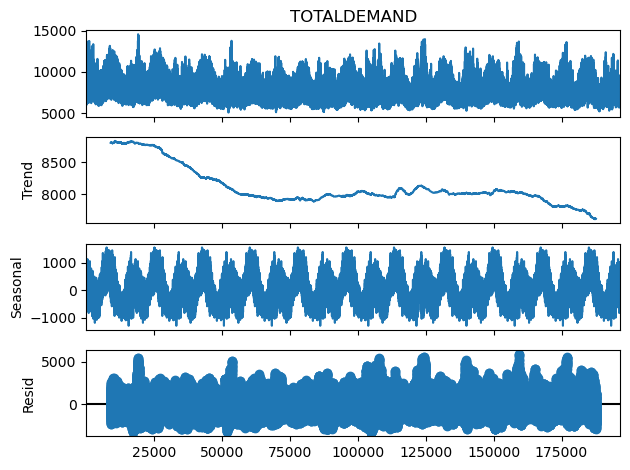

In [37]:
import statsmodels.api as sm

decomp = sm.tsa.seasonal_decompose(df3['TOTALDEMAND'], period=48*365) 
print(decomp.seasonal.head())
_ = decomp.plot()

## Feature Correlation

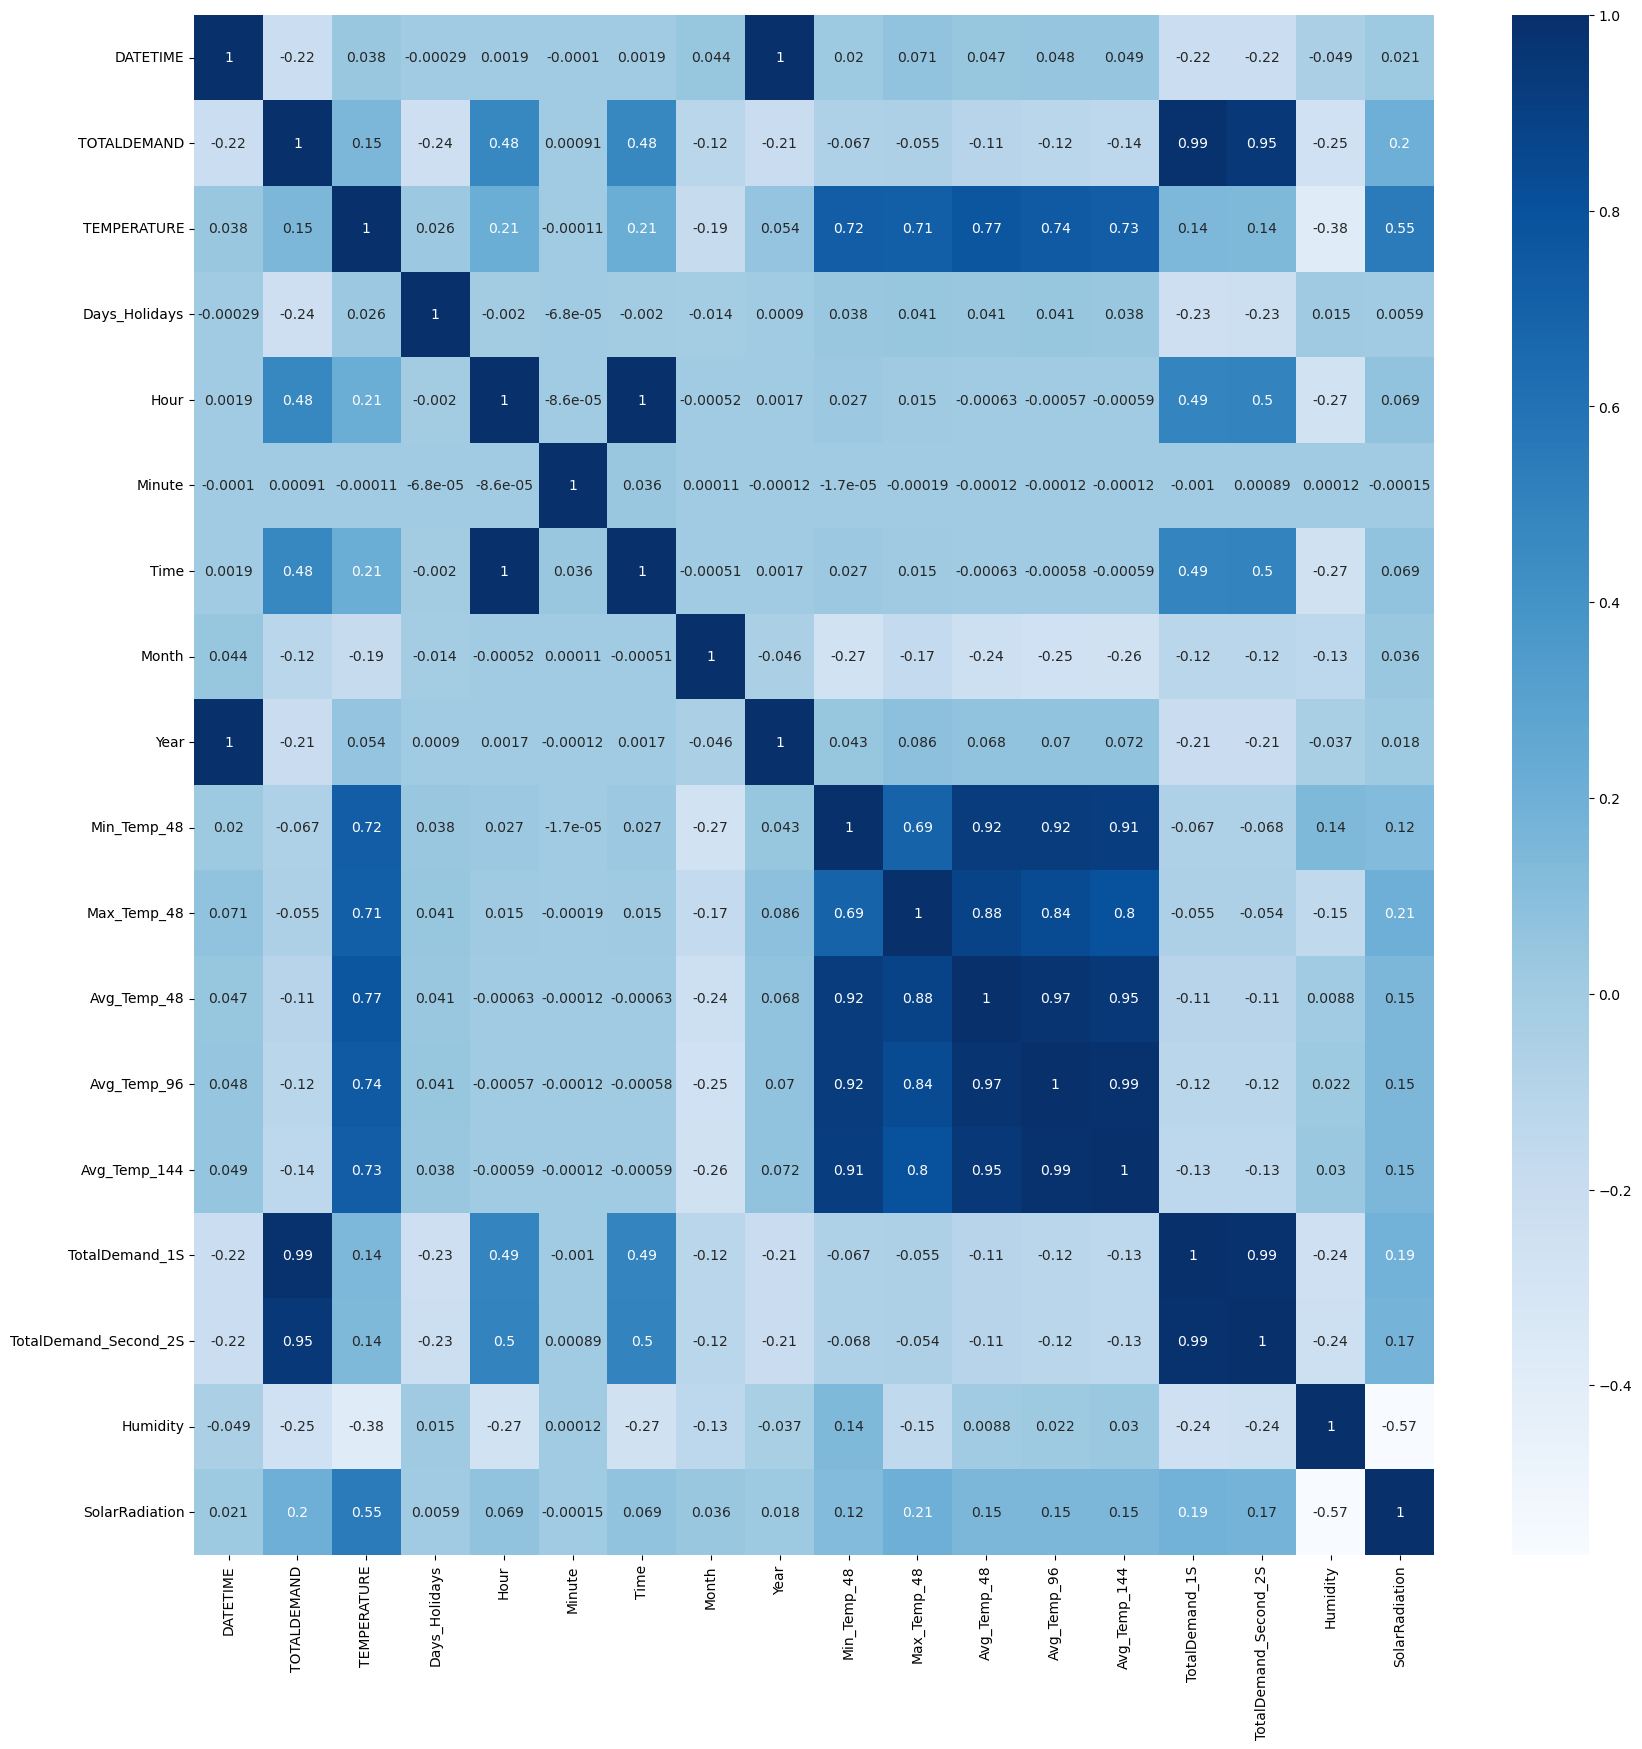

In [92]:
plt.subplots(figsize=(20, 20))
corr_heatmap = sns.heatmap(df3.corr(method='pearson'), cmap="Blues", annot=True)

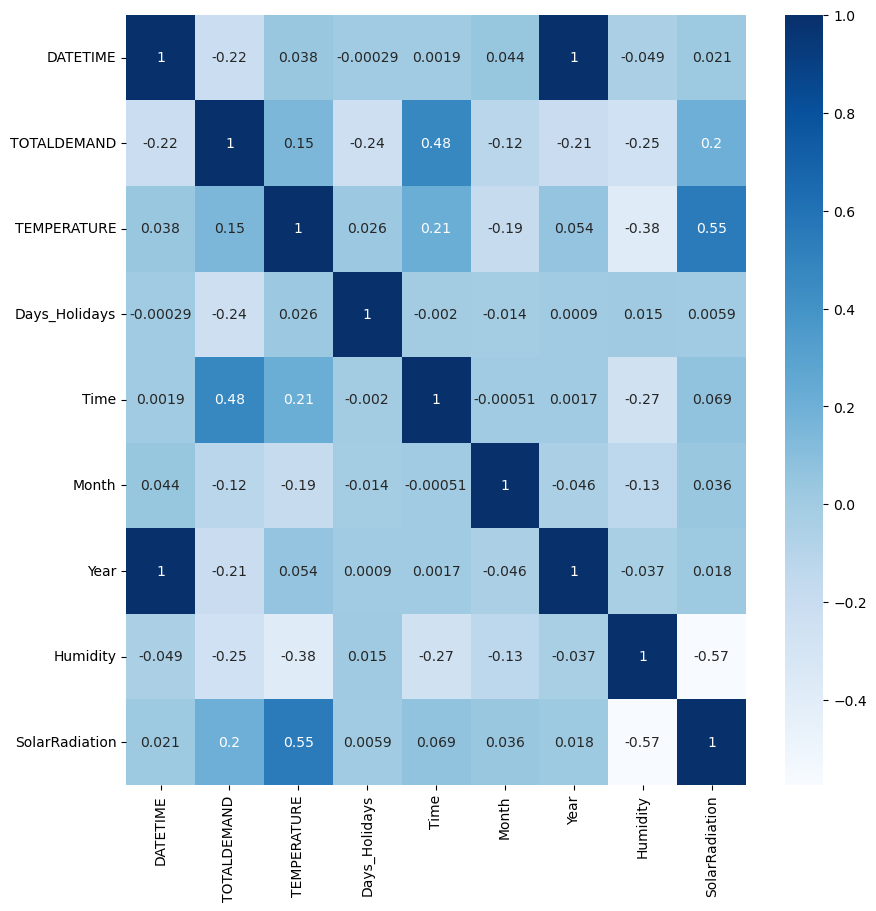

In [91]:
plt.figure(figsize=(10, 10))
sns.heatmap(df3.drop(columns=['Hour', 'Minute','Min_Temp_48', 'Max_Temp_48', 'Avg_Temp_48', 'Avg_Temp_96', 'Avg_Temp_144','TotalDemand_1S', 'TotalDemand_Second_2S',], errors='ignore').corr(method='pearson'), cmap="Blues", annot=True)
plt.show()

## One Hot Encoding and Transforming Time Due to Cyclic Nature

In [42]:
# One-hot encode 'Days_Holidays' and 'Month'
df3_encoded = pd.get_dummies(df3, columns=['Days_Holidays', 'Month'])
df3_encoded['Time_sin'] = np.sin(2 * np.pi * df3_encoded['Time'] / 48)
df3_encoded['Time_cos'] = np.cos(2 * np.pi * df3_encoded['Time'] / 48)
df3_encoded.drop(['Hour','Minute','Time'], axis=1, inplace=True)
df3_encoded.set_index('DATETIME', inplace=True)
print(df3_encoded)

                     TOTALDEMAND  TEMPERATURE  Year  Min_Temp_48  Max_Temp_48  \
DATETIME                                                                        
2010-01-01 01:00:00      7483.69         22.6  2010         22.6         23.1   
2010-01-01 01:30:00      7117.23         22.5  2010         22.5         23.1   
2010-01-01 02:00:00      6812.03         22.5  2010         22.5         23.1   
2010-01-01 02:30:00      6544.33         22.4  2010         22.4         23.1   
2010-01-01 03:00:00      6377.32         22.3  2010         22.3         23.1   
...                          ...          ...   ...          ...          ...   
2021-03-17 22:00:00      7419.77         19.7  2021         16.1         22.6   
2021-03-17 22:30:00      7417.91         19.5  2021         16.1         22.6   
2021-03-17 23:00:00      7287.32         19.1  2021         16.1         22.6   
2021-03-17 23:30:00      7172.39         18.8  2021         16.1         22.6   
2021-03-18 00:00:00      709

## Split data into train/test

In [54]:
# Select features and target
X = df3_encoded[['TEMPERATURE', 'Year', 'Min_Temp_48', 'Max_Temp_48', 'Avg_Temp_48', 'Avg_Temp_96', 'Avg_Temp_144', 'TotalDemand_1S', 'TotalDemand_Second_2S', 'Humidity', 'SolarRadiation', 'Days_Holidays_0', 'Days_Holidays_1', 'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Time_sin', 'Time_cos']]
y = df3_encoded['TOTALDEMAND']


# Define training and testing periods
train_start_dt = '2010-01-01 00:00:00'
test_start_dt = '2019-01-01 00:00:00'

# Split data into training and testing sets
train = df3_encoded[(df3_encoded.index >= train_start_dt) & (df3_encoded.index < test_start_dt)].copy()
test = df3_encoded[df3_encoded.index >= test_start_dt].copy()

# Display the split data
print(f"Training data: {train.shape[0]} rows")
print(f"Testing data: {test.shape[0]} rows")

Training data: 155580 rows
Testing data: 38267 rows


## SVR Model

In [55]:
# Select features and target
X_train = train[['TEMPERATURE', 'Year', 'Min_Temp_48', 'Max_Temp_48', 'Avg_Temp_48', 'Avg_Temp_96', 'Avg_Temp_144', 'TotalDemand_1S', 'TotalDemand_Second_2S', 'Humidity', 'SolarRadiation', 'Days_Holidays_0', 'Days_Holidays_1', 'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Time_sin', 'Time_cos']]
y_train = train['TOTALDEMAND']

X_test = test[['TEMPERATURE', 'Year', 'Min_Temp_48', 'Max_Temp_48', 'Avg_Temp_48', 'Avg_Temp_96', 'Avg_Temp_144', 'TotalDemand_1S', 'TotalDemand_Second_2S', 'Humidity', 'SolarRadiation', 'Days_Holidays_0', 'Days_Holidays_1', 'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10', 'Month_11', 'Month_12', 'Time_sin', 'Time_cos']]
y_test = test['TOTALDEMAND']

# Standardize the features (important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SVR model
svr = SVR(kernel='rbf', gamma=0.5, C=10, epsilon=0.05)

# Train the model
svr.fit(X_train_scaled, y_train)

# Make predictions
y_pred = svr.predict(X_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae}')
print(f'MAPE: {mape * 100}%')
print(f"MSE: {mse}")
print(f"R² Score: {r2}")

MAE: 941.9068478076605
MAPE: 12.575829801299124%
MSE: 1413057.8036071493
R² Score: 0.09766517380709283


## Long Short Term Memory Model (LSTM)

#### 1 step ahead model

In [56]:
%%time 
## 1 step ahead

features = ['TEMPERATURE', 'TOTALDEMAND']

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i, 1])  # Predict TOTALDEMAND at 1 step ahead
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144 # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Reshape the input for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 2))  
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 2))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1)) 

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions back to original scale
y_test_rescaled = scaler.inverse_transform(np.concatenate((np.zeros((y_test.shape[0], 1)), y_test.reshape(-1, 1)), axis=1))[:, 1]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((np.zeros((y_pred.shape[0], 1)), y_pred), axis=1))[:, 1]

# Evaluate the model
mae1 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape1 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse1 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'Baseline LSTM Model \n 1 feature, 1 target, 1 step ahead')
print(f'MAE: {mae1}')
print(f'MAPE: {mape1}')
print(f'MSE: {mse1}')

#time was too long at 20 epoch, adjusted to 5 based on loss and val_loss analysis

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 866s 356ms/step - loss: 0.0049 - val_loss: 3.2435e-04
Epoch 2/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 171s 70ms/step - loss: 4.2951e-04 - val_loss: 1.3508e-04
Epoch 3/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 174s 72ms/step - loss: 3.4215e-04 - val_loss: 1.3937e-04
Epoch 4/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 175s 72ms/step - loss: 3.1753e-04 - val_loss: 2.2846e-04
Epoch 5/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 171s 71ms/step - loss: 2.9752e-04 - val_loss: 1.6558e-04
1192/1192 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step
Baseline LSTM Model 
 1 feature, 1 target, 1 step ahead
MAE: 94.65776669236743
MAPE: 0.012210267939912157
MSE: 14959.801465734447
CPU times: user 14min 13s, sys: 1min 24s, total: 15min 37s
Wall time: 26min 11s


#### 45 step ahead model

In [57]:
%%time 
#45 steps ahead

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense

# Features to be used for LSTM input
features = ['TEMPERATURE', 'TOTALDEMAND']

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[features])
test_scaled = scaler.transform(test[features])

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 1])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
scaler_demand = MinMaxScaler(feature_range=(0, 1))
scaler_demand.min_, scaler_demand.scale_ = scaler.min_[1], scaler.scale_[1]

y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae2 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape2 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse2 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'Baseline LSTM Model \n 1 feature, 1 target, 45 step ahead')
print(f'MAE: {mae2}')
print(f'MAPE: {mape2}')
print(f'MSE: {mse2}')

Epoch 1/5


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2428/2428 ━━━━━━━━━━━━━━━━━━━━ 155s 63ms/step - loss: 0.0069 - val_loss: 0.0054
Epoch 2/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 156s 64ms/step - loss: 0.0042 - val_loss: 0.0046
Epoch 3/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 156s 64ms/step - loss: 0.0036 - val_loss: 0.0047
Epoch 4/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 156s 64ms/step - loss: 0.0034 - val_loss: 0.0043
Epoch 5/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 156s 64ms/step - loss: 0.0032 - val_loss: 0.0044
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step
Baseline LSTM Model 
 1 feature, 1 target, 45 step ahead
MAE: 438.30854588025477
MAPE: 0.05567849828916039
MSE: 401091.0363357743
CPU times: user 12min 51s, sys: 1min 26s, total: 14min 18s
Wall time: 13min 13s


#### 45 step ahead model - additional features

In [64]:
%%time 
#45 step ahead additional features

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae3 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape3 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse3 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 7 features, 45 step ahead')
print(f'MAE: {mae3}')
print(f'MAPE: {mape3}')
print(f'MSE: {mse3}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 165s 67ms/step - loss: 0.0066 - val_loss: 0.0036
Epoch 2/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 160s 66ms/step - loss: 0.0024 - val_loss: 0.0039
Epoch 3/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 159s 66ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 4/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 494s 204ms/step - loss: 0.0021 - val_loss: 0.0038
Epoch 5/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - loss: 0.0021 - val_loss: 0.0034
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step
LSTM Model 
 7 features, 45 step ahead
MAE: 357.8100079650406
MAPE: 0.04509010971998805
MSE: 311321.52178106963
CPU times: user 13min 36s, sys: 1min 23s, total: 15min
Wall time: 19min 21s


#### 45 step ahead model - additional features + Solar Radiation and Humidity

In [65]:
%%time 
#45 step ahead additional features

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae4 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape4 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse4 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead')
print(f'MAE: {mae4}')
print(f'MAPE: {mape4}')
print(f'MSE: {mse4}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 167s 68ms/step - loss: 0.0062 - val_loss: 0.0038
Epoch 2/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - loss: 0.0024 - val_loss: 0.0037
Epoch 3/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 4/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 164s 67ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 5/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 164s 67ms/step - loss: 0.0020 - val_loss: 0.0035
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step
LSTM Model 
 9 features, 45 step ahead
MAE: 349.234640779182
MAPE: 0.043991233680674195
MSE: 312566.78232504724
CPU times: user 13min 38s, sys: 1min 32s, total: 15min 11s
Wall time: 14min 3s


#### 45 step ahead model - additional features + Solar Radiation and Humidity with 50 epochs and early stopping

In [75]:
%%time 
# 45 step ahead additional features with early stopping

from keras.callbacks import EarlyStopping

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae7 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape7 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse7 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n 50 epochs with early stopping')
print(f'MAE: {mae7}')
print(f'MAPE: {mape7}')
print(f'MSE: {mse7}')


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 171s 70ms/step - loss: 0.0062 - val_loss: 0.0037
Epoch 2/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 165s 68ms/step - loss: 0.0024 - val_loss: 0.0035
Epoch 3/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 164s 68ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 4/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - loss: 0.0021 - val_loss: 0.0033
Epoch 5/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 165s 68ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 6/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 7/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 166s 68ms/step - loss: 0.0018 - val_loss: 0.0036
Epoch 8/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 162s 67ms/step - loss: 0.0018 - val_loss: 0.0039
Epoch 9/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 164s 67ms/step - loss: 0.0017 - val_loss: 0.0038
Epoch 10/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 168s 69ms/step - loss: 0.0016 - val_loss: 0.0042
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step
LSTM Model 
 9 features, 45 step ahead 
 50 

In [93]:
%%time 
# 45 step ahead additional features with early stopping

from keras.callbacks import EarlyStopping

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 336  # 7 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae8 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape8 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse8 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n 50 epochs with early stopping \n longer sequence length')
print(f'MAE: {mae8}')
print(f'MAPE: {mape8}')
print(f'MSE: {mse8}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 377s 155ms/step - loss: 0.0051 - val_loss: 0.0034
Epoch 2/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 2271s 937ms/step - loss: 0.0023 - val_loss: 0.0033
Epoch 3/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 3289s 1s/step - loss: 0.0021 - val_loss: 0.0033
Epoch 4/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 2944s 1s/step - loss: 0.0020 - val_loss: 0.0034
Epoch 5/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 3838s 2s/step - loss: 0.0020 - val_loss: 0.0034
Epoch 6/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 4288s 2s/step - loss: 0.0018 - val_loss: 0.0034
Epoch 7/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 5126s 2s/step - loss: 0.0018 - val_loss: 0.0033
Epoch 8/50
2425/2425 ━━━━━━━━━━━━━━━━━━━━ 5322s 2s/step - loss: 0.0017 - val_loss: 0.0037
1184/1184 ━━━━━━━━━━━━━━━━━━━━ 1013s 856ms/step
LSTM Model 
 9 features, 45 step ahead 
 50 epochs with early stopping 
 longer sequence length
MAE: 351.5917174225534
MAPE: 0.04418266025066836
MSE: 298109.10371871403
CPU times: user 49min 52s, sys: 6min 19s, total: 56min 11s

#### 45 step ahead model - additional features + Solar Radiation and Humidity - optimizer changed to SGD

In [69]:
%%time 
#45 step ahead additional features

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='sgd', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae5 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape5 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse5 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n SGD Optimizer')
print(f'MAE: {mae5}')
print(f'MAPE: {mape5}')
print(f'MSE: {mse5}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 161s 66ms/step - loss: 0.0133 - val_loss: 0.0067
Epoch 2/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 158s 65ms/step - loss: 0.0068 - val_loss: 0.0061
Epoch 3/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 2029s 836ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 4/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 165s 68ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 5/5
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - loss: 0.0051 - val_loss: 0.0053
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step
LSTM Model 
 9 features, 45 step ahead 
 SGD Optimizer
MAE: 501.15004180864133
MAPE: 0.06257251799018446
MSE: 479027.32505690807
CPU times: user 13min 35s, sys: 1min 27s, total: 15min 2s
Wall time: 44min 56s


SGD performs worse than Adam with the same parameters and variables, stick with Adam.

#### 24 step ahead model - additional features + Solar Radiation and Humidity

In [71]:
%%time 
#24 step ahead additional features

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 23):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 23, 0])  # Predict the 24th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=25))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae6 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape6 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse6 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 24 step ahead')
print(f'MAE: {mae6}')
print(f'MAPE: {mape6}')
print(f'MSE: {mse6}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 184s 75ms/step - loss: 0.0073 - val_loss: 0.0035
Epoch 2/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 181s 75ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 3/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 178s 73ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 4/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 177s 73ms/step - loss: 0.0018 - val_loss: 0.0034
Epoch 5/5
2429/2429 ━━━━━━━━━━━━━━━━━━━━ 917s 378ms/step - loss: 0.0017 - val_loss: 0.0030
1191/1191 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step
LSTM Model 
 9 features, 24 step ahead
MAE: 350.3594405593832
MAPE: 0.04418368035484776
MSE: 267868.0326030877
CPU times: user 15min 4s, sys: 1min 30s, total: 16min 35s
Wall time: 27min 37s


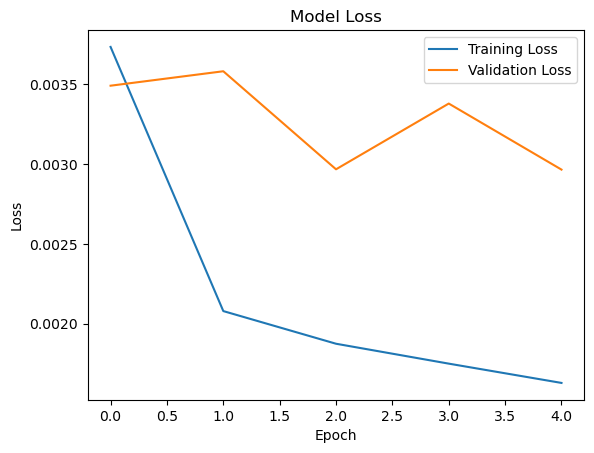

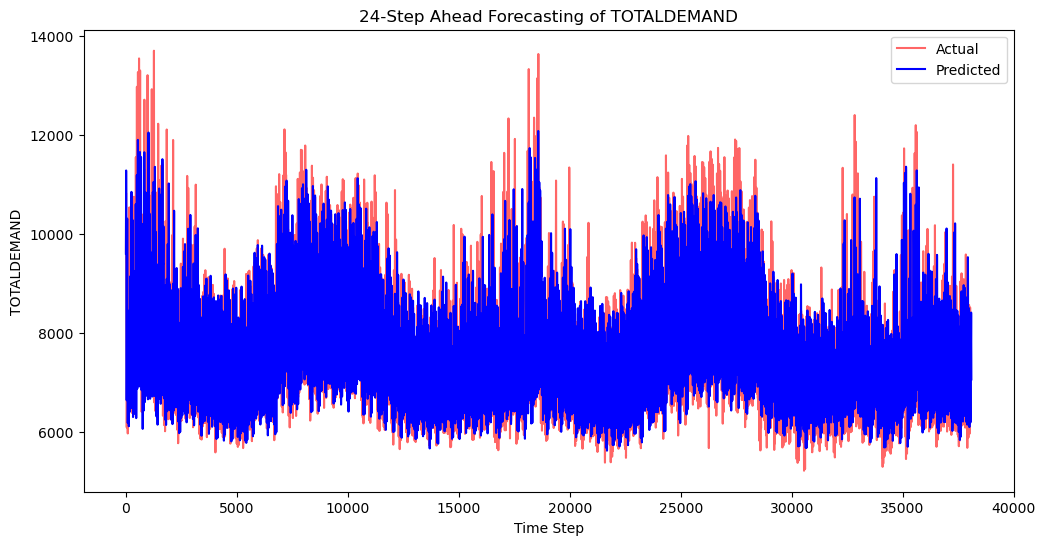

In [73]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[45:], label="Actual", color='red', alpha=0.6)
plt.plot(y_pred_rescaled, label="Predicted", color='blue')
plt.title('24-Step Ahead Forecasting of TOTALDEMAND')
plt.xlabel('Time Step')
plt.ylabel('TOTALDEMAND')
plt.legend()
plt.show()

#### Keras Tuner - Random Search

In [115]:
from kerastuner import HyperModel, RandomSearch

class LSTMHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(LSTM(units=hp.Int('units', min_value=32, max_value=128, step=16),
                       return_sequences=True,
                       input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
        model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=16), return_sequences=False))
        model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))
        model.add(Dense(units=hp.Int('dense_units', min_value=10, max_value=50, step=10)))
        model.add(Dense(units=1))
        model.compile(optimizer='adam', loss='mean_squared_error')
        return model

tuner = RandomSearch(
    LSTMHyperModel(),
    objective='val_loss',
    max_trials=5,  
    executions_per_trial=3,
    directory='hyperparam_tuning',
    project_name='lstm_tuning2'
)

tuner.search(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

Trial 5 Complete [05h 34m 54s]
val_loss: 0.003335768279309074

Best val_loss So Far: 0.003335768279309074
Total elapsed time: 1d 00h 15m 21s


In [116]:
tuner.results_summary()

Results summary
Results in hyperparam_tuning/lstm_tuning2
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
units: 80
dropout: 0.2
units_2: 80
dropout_2: 0.1
dense_units: 10
Score: 0.003335768279309074

Trial 1 summary
Hyperparameters:
units: 64
dropout: 0.1
units_2: 80
dropout_2: 0.1
dense_units: 50
Score: 0.003350174520164728

Trial 0 summary
Hyperparameters:
units: 48
dropout: 0.30000000000000004
units_2: 32
dropout_2: 0.5
dense_units: 50
Score: 0.003354256429399053

Trial 3 summary
Hyperparameters:
units: 80
dropout: 0.5
units_2: 32
dropout_2: 0.5
dense_units: 30
Score: 0.0033576899052908025

Trial 2 summary
Hyperparameters:
units: 64
dropout: 0.2
units_2: 80
dropout_2: 0.1
dense_units: 40
Score: 0.0033750794051835933


#### Model updated with Random Search results

In [96]:
%%time 
# 45 step ahead additional features with early stopping

from keras.callbacks import EarlyStopping

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=80, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.1))
model.add(LSTM(units=96, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(units=10))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae9 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape9 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse9 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n 50 epochs with early stopping \n Random Search result optimised')
print(f'MAE: {mae9}')
print(f'MAPE: {mape9}')
print(f'MSE: {mse9}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 349s 143ms/step - loss: 0.0053 - val_loss: 0.0037
Epoch 2/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 344s 142ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 3/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 345s 142ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 4/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 346s 143ms/step - loss: 0.0020 - val_loss: 0.0034
Epoch 5/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 350s 144ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 6/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 366s 151ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 7/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 368s 152ms/step - loss: 0.0017 - val_loss: 0.0041
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step
LSTM Model 
 9 features, 45 step ahead 
 50 epochs with early stopping 
 Random Search result optimised
MAE: 356.19246996991455
MAPE: 0.044360351250529305
MSE: 302143.4109454623
CPU times: user 53min, sys: 11min 45s, total: 1h 4min 46s
Wall time: 41min 54s


In [97]:
%%time 
# 45 step ahead additional features with early stopping

from keras.callbacks import EarlyStopping

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - 44):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + 44, 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=80, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=80, activation='relu', return_sequences=False))
model.add(Dropout(0.1))
model.add(Dense(units=10))
model.add(Dense(units=1))  # Predicting the 45th step ahead

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae10 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape10 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse10 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n 50 epochs with early stopping \n Random Search result optimised \n Different activation function')
print(f'MAE: {mae10}')
print(f'MAPE: {mape10}')
print(f'MSE: {mse10}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 804s 331ms/step - loss: 0.0066 - val_loss: 0.0035
Epoch 2/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 348s 143ms/step - loss: 0.0023 - val_loss: 0.0036
Epoch 3/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 1280s 528ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 4/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 326s 134ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 5/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 318s 131ms/step - loss: 0.0019 - val_loss: 0.0047
Epoch 6/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 324s 133ms/step - loss: 0.0018 - val_loss: 0.0041
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step
LSTM Model 
 9 features, 45 step ahead 
 50 epochs with early stopping 
 Random Search result optimised 
 Different activation function
MAE: 361.514797731874
MAPE: 0.04502736901394039
MSE: 311931.353278829
CPU times: user 43min 28s, sys: 8min 56s, total: 52min 24s
Wall time: 57min 20s


### Most accurate model

In [113]:
%%time 
# 45 step ahead additional features with early stopping

from keras.callbacks import EarlyStopping

# Features to be used for LSTM input
features = ['TOTALDEMAND', 'TEMPERATURE', 'Year', 'Time_sin', 'Time_cos', 'SolarRadiation', 'Humidity',
            'TotalDemand_1S', 'TotalDemand_Second_2S', 'Days_Holidays_0', 'Days_Holidays_1', 
            'Days_Holidays_2', 'Days_Holidays_3', 'Days_Holidays_4', 'Days_Holidays_5', 'Days_Holidays_6', 'Days_Holidays_7', 
            'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 
            'Month_10', 'Month_11','Month_12']

# Normalize all features except TOTALDEMAND
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled_features = scaler.fit_transform(train[features].drop(columns=['TOTALDEMAND']))
test_scaled_features = scaler.transform(test[features].drop(columns=['TOTALDEMAND']))

# Scale TOTALDEMAND separately
scaler_demand = MinMaxScaler(feature_range=(0, 1))
train_scaled_demand = scaler_demand.fit_transform(train[['TOTALDEMAND']])
test_scaled_demand = scaler_demand.transform(test[['TOTALDEMAND']])

# Combine scaled TOTALDEMAND and other features
train_scaled = np.hstack((train_scaled_demand, train_scaled_features))
test_scaled = np.hstack((test_scaled_demand, test_scaled_features))

steps_ahead = 45

# Function to create sequences of data for LSTM
def create_sequences(data, sequence_length):
    X = []
    y = []
    # Adjust the loop to avoid out-of-bounds error
    for i in range(sequence_length, len(data) - steps_ahead - 1):
        X.append(data[i-sequence_length:i, :])  # Past sequence_length observations
        y.append(data[i + steps_ahead - 1 , 0])  # Predict the 45th step ahead for TOTALDEMAND
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 144  # 3 day window 

# Create sequences for training and testing sets
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=80, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.1))
model.add(LSTM(units=96, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(units=10))
model.add(Dense(units=1)) 

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[early_stopping])

# Make predictions on the test set
y_pred = model.predict(X_test)

# Rescale the predictions and actual values back to the original scale
y_test_rescaled = scaler_demand.inverse_transform(y_test.reshape(-1, 1))
y_pred_rescaled = scaler_demand.inverse_transform(y_pred)

# Evaluate the model
mae11 = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
mape11 = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
mse11 = mean_squared_error(y_test_rescaled, y_pred_rescaled)
print(f'LSTM Model \n 9 features, 45 step ahead \n 50 epochs with early stopping \n Random Search result optimised')
print(f'MAE: {mae11}')
print(f'MAPE: {mape11}')
print(f'MSE: {mse11}')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 353s 145ms/step - loss: 0.0067 - val_loss: 0.0035
Epoch 2/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 357s 147ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 3/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 364s 150ms/step - loss: 0.0021 - val_loss: 0.0039
Epoch 4/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 358s 147ms/step - loss: 0.0020 - val_loss: 0.0039
Epoch 5/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 359s 148ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 6/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 352s 145ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 7/50
2428/2428 ━━━━━━━━━━━━━━━━━━━━ 360s 148ms/step - loss: 0.0017 - val_loss: 0.0035
1190/1190 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step
LSTM Model 
 9 features, 45 step ahead 
 50 epochs with early stopping 
 Random Search result optimised
MAE: 356.5405509297977
MAPE: 0.04429447350170884
MSE: 299547.11937817547
CPU times: user 53min 42s, sys: 11min 36s, total: 1h 5min 18s
Wall time: 42min 27s
